# Analyse des Betriebsverhaltens einer Turbomaschine

In [6]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### 1. Messdaten laden und anzeigen

Dieser Abschnitt lädt die Messdaten aus einer CSV-Datei und zeigt die ersten Zeilen zur Überprüfung an.

In [7]:
# Dateipfad der Messdaten
filename = '/content/volume_flow_data.csv'

# Messdaten in DataFrame laden
df = pd.read_csv(filename)

# Erste Zeilen anzeigen
display(df.head())

,Timestamp,Volume Flow (m^3/h)
0,2024-04-01 00:00:00,312.54
1,2024-04-01 00:01:00,193.78
2,2024-04-01 00:02:00,393.96
3,2024-04-01 00:03:00,364.70
4,2024-04-01 00:04:00,100.33


### 2. Pumpenkennfelder definieren

Hier werden die Leistungsdaten der Pumpe (Volumenstrom, Förderhöhe, Wirkungsgrad) definiert und Interpolationsfunktionen erstellt.

In [8]:
# Stützpunkte des Pumpenkennfelds (Herstellerdaten)
Q_points = np.array([0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 560]) # Volumenstrom (m³/h)
H_points = np.array([23.4, 23.0, 22.5, 22.0, 21.2, 20.0, 18.5, 17.0, 15.2, 13.2, 11.2, 8.8]) # Förderhöhe (m)
eta_points = np.array([0.01, 25.0, 45.0, 55.0, 64.0, 71.3, 73.5, 74.5, 75.0, 74.0, 72.0, 68.0]) / 100.0 # Wirkungsgrad

# Kubische Interpolationsfunktionen erstellen
f_H = interp1d(Q_points, H_points, kind='cubic', fill_value='extrapolate')
f_eta = interp1d(Q_points, eta_points, kind='cubic', fill_value='extrapolate')

### 3. Datenvorbereitung und Glättung

Dieser Abschnitt bereitet die Messdaten auf, indem Zeitstempel formatiert, die Förderhöhe und der Wirkungsgrad berechnet und der Volumenstrom geglättet werden.

In [9]:
# Spaltenname für Volumenstrom
col_flow = 'Volume Flow (m^3/h)'

# Zeitstempel formatieren
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Förderhöhe (H_m) und Wirkungsgrad (eta) berechnen
df['H_m'] = f_H(df[col_flow])
df['eta'] = np.clip(f_eta(df[col_flow]), 0.01, 1.0) # Wirkungsgrad begrenzen (min. 1%)

# Volumenstrom glätten (gleitender Mittelwert über 15 Minuten)
df['Q_smoothed'] = df[col_flow].rolling(window=15, min_periods=1).mean()

### 4. Physikalische und Wirtschaftliche Berechnungen

Hier werden hydraulische und elektrische Leistungen, Energieverbräuche sowie die entsprechenden Kosten berechnet.

In [10]:
# Konstanten
rho = 1000 # Dichte Wasser (kg/m³)
g = 9.81   # Erdbeschleunigung (m/s²)
strompreis = 0.18 # Strompreis (€ / kWh)
delta_t_h = 1 / 60 # Messintervall in Stunden (1 Minute)

# Hydraulische Leistung (Watt)
df['P_hyd_W'] = rho * g * (df[col_flow] / 3600) * df['H_m']

# Elektrische Leistung (Watt)
df['P_el_W'] = df['P_hyd_W'] / df['eta']

# Energieberechnung (kWh)
df['E_hyd_kWh'] = (df['P_hyd_W'] / 1000) * delta_t_h
df['E_el_kWh'] = (df['P_el_W'] / 1000) * delta_t_h
df['E_loss_kWh'] = df['E_el_kWh'] - df['E_hyd_kWh']

# Kostenraten (€/h)
df['Cost_Rate_hyd'] = (df['P_hyd_W'] / 1000) * strompreis
df['Cost_Rate_loss'] = ((df['P_el_W'] - df['P_hyd_W']) / 1000) * strompreis

# Geglättete Werte für Leistung und Kosten
df['P_el_smooth'] = df['P_el_W'].rolling(window=15, min_periods=1).mean()
df['P_hyd_smooth'] = df['P_hyd_W'].rolling(window=15, min_periods=1).mean()
df['Cost_hyd_smooth'] = df['Cost_Rate_hyd'].rolling(window=15, min_periods=1).mean()
df['Cost_loss_smooth'] = df['Cost_Rate_loss'].rolling(window=15, min_periods=1).mean()

### 5. Numerische Zusammenfassung

Dieser Abschnitt zeigt eine technische und wirtschaftliche Zusammenfassung der Betriebsdaten, einschließlich Energieverbrauch, Effizienz und Kosten.

In [11]:
# Gesamtenergie und Effizienz
total_el_kWh = df['E_el_kWh'].sum()
total_hyd_kWh = df['E_hyd_kWh'].sum()
total_loss_kWh = df['E_loss_kWh'].sum()
avg_eff = (total_hyd_kWh / total_el_kWh) * 100

# Gesamtkosten
total_cost = total_el_kWh * strompreis
loss_cost = total_loss_kWh * strompreis

# Durchschnittliche Leistung
avg_P_hyd_W = df['P_hyd_W'].mean()
avg_P_el_W = df['P_el_W'].mean()

print("--- TECHNISCHE AUSWERTUNG ---")
print(f"Gesamtverbrauch (elektrisch): {total_el_kWh:.2f} kWh")
print(f"Verlustenergie:               {total_loss_kWh:.2f} kWh")
print(f"Durchschnittliche Effizienz:  {avg_eff:.2f} %")
print(f"Durchschnittliche hydraulische Leistung: {avg_P_hyd_W / 1000:.2f} kW")
print(f"Durchschnittliche elektrische Leistung: {avg_P_el_W / 1000:.2f} kW")

print("\n--- WIRTSCHAFTLICHE AUSWERTUNG ---")
print(f"Gesamte Stromkosten:          {total_cost:.2f} €")
print(f"Kosten durch Ineffizienz:     {loss_cost:.2f} €")
print("----------------------------------------------")

--- TECHNISCHE AUSWERTUNG ---
Gesamtverbrauch (elektrisch): 457.81 kWh
Verlustenergie:               146.82 kWh
Durchschnittliche Effizienz:  67.93 %
Durchschnittliche hydraulische Leistung: 12.96 kW
Durchschnittliche elektrische Leistung: 19.08 kW

--- WIRTSCHAFTLICHE AUSWERTUNG ---
Gesamte Stromkosten:          82.41 €
Kosten durch Ineffizienz:     26.43 €
----------------------------------------------


### 6. Visualisierung des Betriebsverhaltens

Dieser Abschnitt visualisiert die wichtigsten Betriebsdaten der Turbomaschine über den gesamten Messzeitraum.

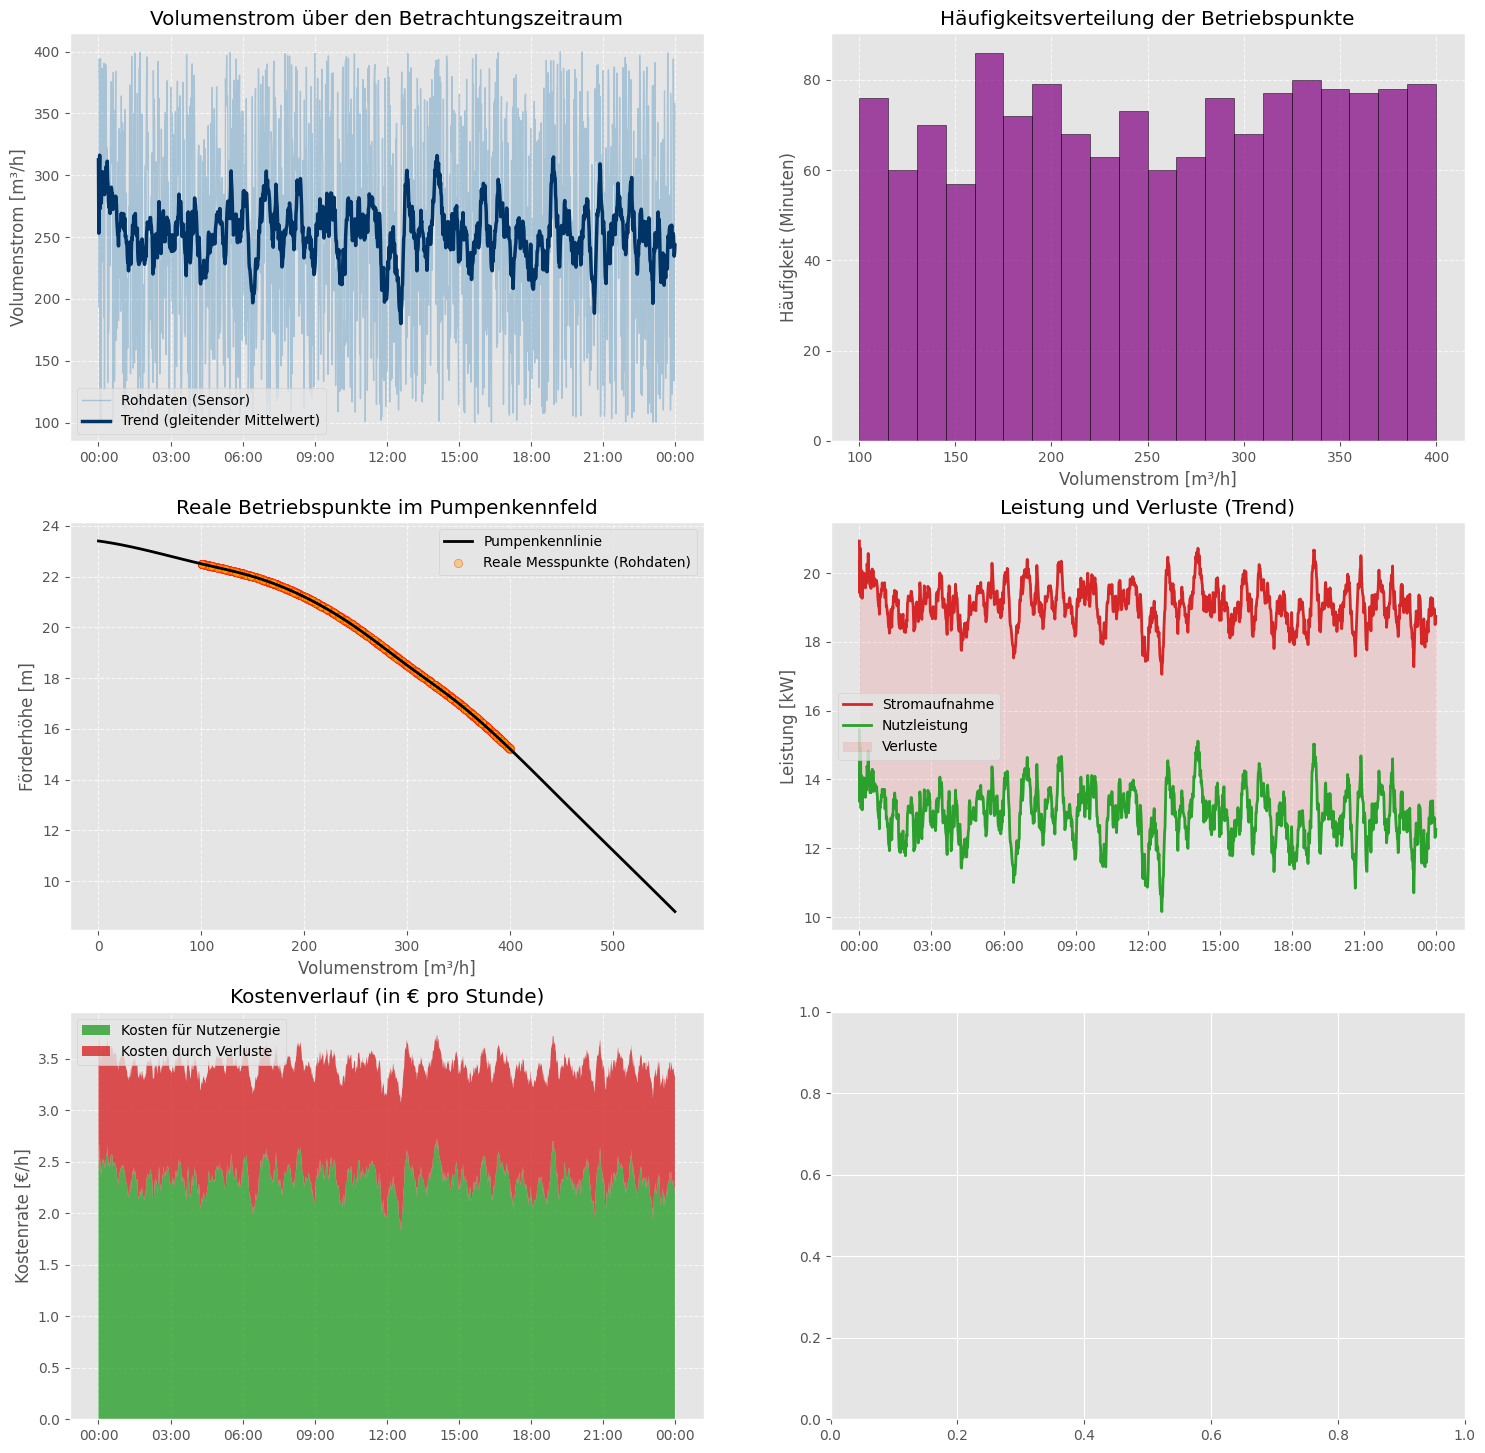

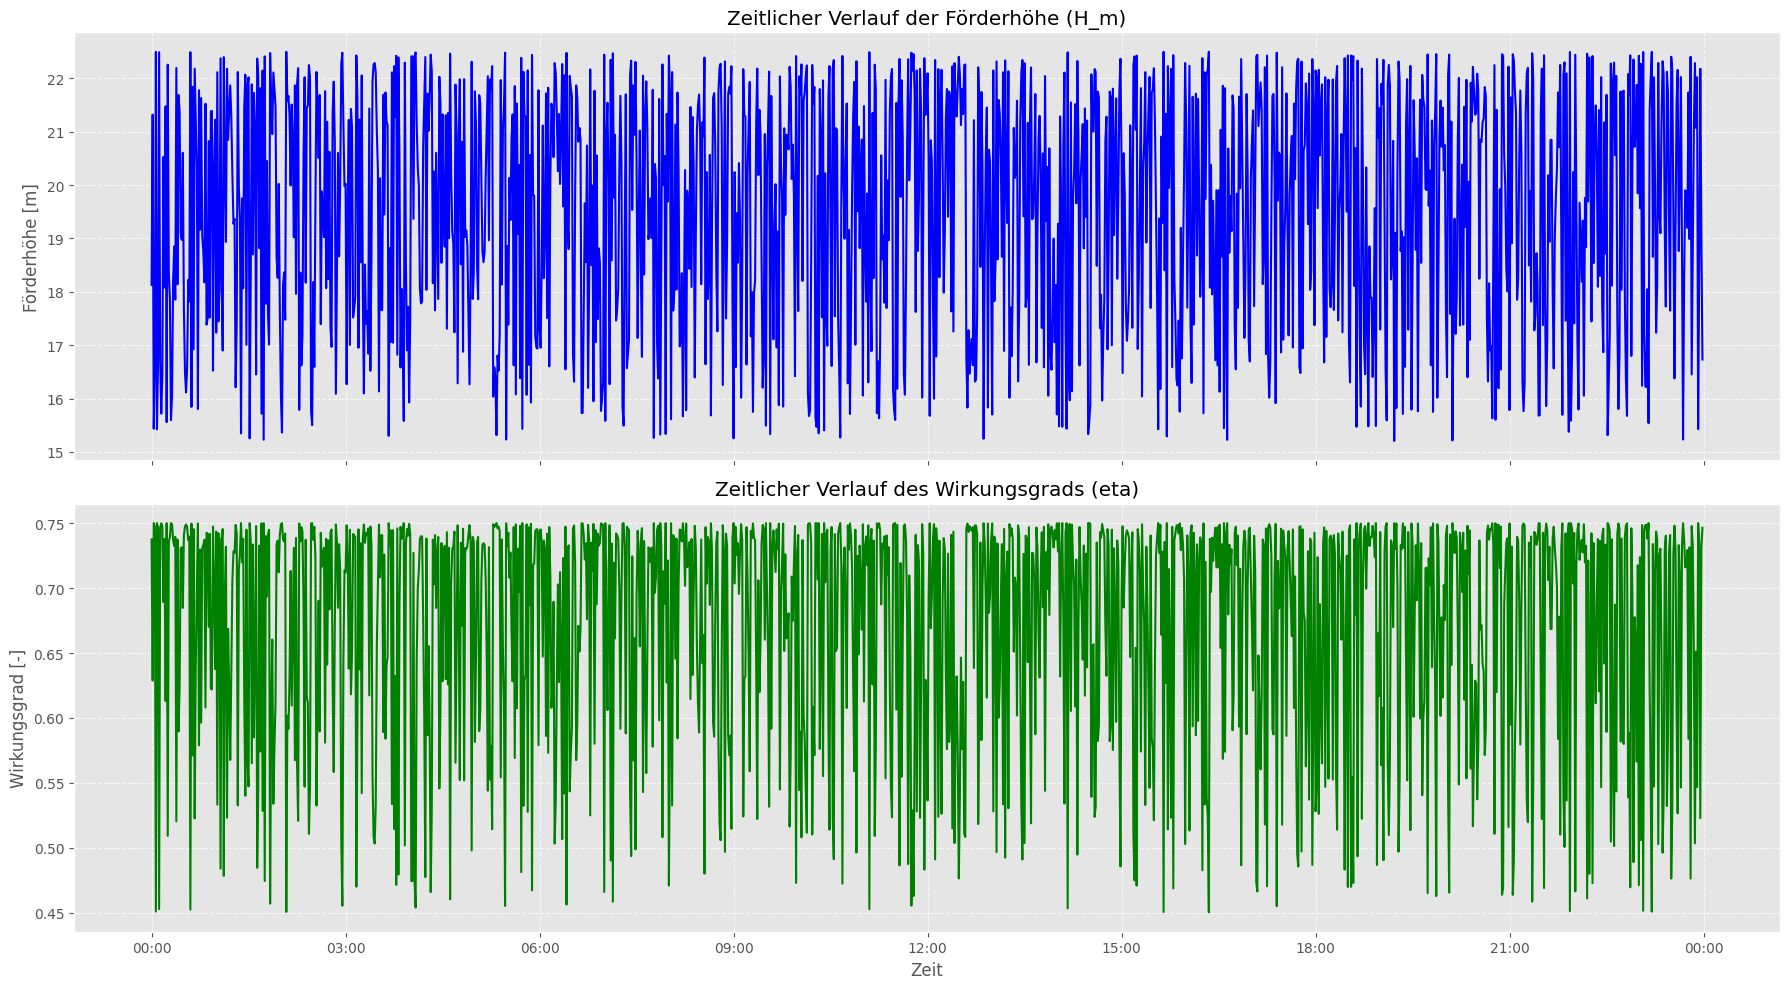

<Figure size 640x480 with 0 Axes>

In [12]:
plt.style.use('ggplot')
fig, axs = plt.subplots(3, 2, figsize=(18, 18))

# Plot 1: Volumenstrom (Zeitverlauf)
axs[0, 0].plot(df['Timestamp'], df[col_flow], color='#1f77b4', alpha=0.3, linewidth=1, label='Rohdaten (Sensor)')
axs[0, 0].plot(df['Timestamp'], df['Q_smoothed'], color='#003366', linewidth=2.5, label='Trend (gleitender Mittelwert)')
axs[0, 0].set_title('Volumenstrom über den Betrachtungszeitraum')
axs[0, 0].set_ylabel('Volumenstrom [m³/h]')
axs[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Histogramm der Betriebspunkte
axs[0, 1].hist(df[col_flow], bins=20, color='purple', alpha=0.7, edgecolor='black')
axs[0, 1].set_title('Häufigkeitsverteilung der Betriebspunkte')
axs[0, 1].set_xlabel('Volumenstrom [m³/h]')
axs[0, 1].set_ylabel('Häufigkeit (Minuten)')
axs[0, 1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: H-Q Kennfeld mit realen Messpunkten
Q_smooth_line = np.linspace(min(Q_points), max(Q_points), 100)
axs[1, 0].plot(Q_smooth_line, f_H(Q_smooth_line), color='black', linewidth=2, label='Pumpenkennlinie')
axs[1, 0].scatter(df[col_flow], df['H_m'], color='orange', alpha=0.4, edgecolor='red', label='Reale Messpunkte (Rohdaten)')
axs[1, 0].set_title('Reale Betriebspunkte im Pumpenkennfeld')
axs[1, 0].set_xlabel('Volumenstrom [m³/h]')
axs[1, 0].set_ylabel('Förderhöhe [m]')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 4: Leistungsvergleich (elektrisch vs. hydraulisch)
axs[1, 1].plot(df['Timestamp'], df['P_el_smooth']/1000, label='Stromaufnahme', color='#d62728', linewidth=2)
axs[1, 1].plot(df['Timestamp'], df['P_hyd_smooth']/1000, label='Nutzleistung', color='#2ca02c', linewidth=2)
axs[1, 1].fill_between(df['Timestamp'], df['P_hyd_smooth']/1000, df['P_el_smooth']/1000, color='red', alpha=0.1, label='Verluste')
axs[1, 1].set_title('Leistung und Verluste (Trend)')
axs[1, 1].set_ylabel('Leistung [kW]')
axs[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle='--', alpha=0.7)

# Plot 5: Stromkosten (Stacked Area)
axs[2, 0].stackplot(df['Timestamp'], df['Cost_hyd_smooth'], df['Cost_loss_smooth'],
                    labels=['Kosten für Nutzenergie', 'Kosten durch Verluste'],
                    colors=['#2ca02c', '#d62728'], alpha=0.8)
axs[2, 0].set_title('Kostenverlauf (in € pro Stunde)')
axs[2, 0].set_ylabel('Kostenrate [€/h]')
axs[2, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2, 0].legend(loc='upper left')
axs[2, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 6: Zeitlicher Verlauf von H_m und eta (im bisher leeren Feld)

# Erstelle neue Subplots für H_m und eta
fig2, (ax_h, ax_eta) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Plot H_m über die Zeit
ax_h.plot(df['Timestamp'], df['H_m'], color='blue', linewidth=1.5)
ax_h.set_title('Zeitlicher Verlauf der Förderhöhe (H_m)')
ax_h.set_ylabel('Förderhöhe [m]')
ax_h.grid(True, linestyle='--', alpha=0.7)

# Plot eta über die Zeit
ax_eta.plot(df['Timestamp'], df['eta'], color='green', linewidth=1.5)
ax_eta.set_title('Zeitlicher Verlauf des Wirkungsgrads (eta)')
ax_eta.set_xlabel('Zeit')
ax_eta.set_ylabel('Wirkungsgrad [-]')
ax_eta.grid(True, linestyle='--', alpha=0.7)
ax_eta.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()

# Sechstes (ursprünglich leeres) Diagrammfeld des ersten Plots ausblenden, da Plots in separaten Figuren erstellt werden
axs[2, 1].axis('off')

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

# Dateiname der Messdaten
filename = '/content/volume_flow_data.csv'

# Messdaten einlesen
df = pd.read_csv(filename)

# Die ersten Zeilen des DataFrames anzeigen
display(df.head())

,Timestamp,Volume Flow (m^3/h)
0,2024-04-01 00:00:00,312.54
1,2024-04-01 00:01:00,193.78
2,2024-04-01 00:02:00,393.96
3,2024-04-01 00:03:00,364.70
4,2024-04-01 00:04:00,100.33


In [14]:
import numpy as np
from scipy.interpolate import interp1d

# ---------------------------------------------------------
# 1. Pumpen-Daten aus dem Hersteller-Datenblatt
# ---------------------------------------------------------
# Stützpunkte aus dem Kennfeld, basierend auf den von Ihnen bereitgestellten Daten
Q_points = np.array([0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 560]) # Volumenstrom in m³/h
H_points = np.array([23.4, 23.0, 22.5, 22.0, 21.2, 20.0, 18.5, 17.0, 15.2, 13.2, 11.2, 8.8]) # Förderhöhe in m
eta_points = np.array([0.01, 25.0, 45.0, 55.0, 64.0, 71.3, 73.5, 74.5, 75.0, 74.0, 72.0, 68.0]) / 100.0 # Wirkungsgrad

# Interpolations-Funktionen zur stetigen Berechnung
f_H = interp1d(Q_points, H_points, kind='cubic', fill_value='extrapolate')
f_eta = interp1d(Q_points, eta_points, kind='cubic', fill_value='extrapolate')

In [15]:
# ---------------------------------------------------------
# 2. Messdaten einlesen & aufbereiten
# ---------------------------------------------------------

# Assuming 'Volume Flow (m^3/h)' is the correct column name from the head output
col_flow = 'Volume Flow (m^3/h)'

# Zeitstempel formatieren
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Förderhöhe und Wirkungsgrad berechnen
df['H_m'] = f_H(df[col_flow])

# Begrenzung des Wirkungsgrads auf minimal 1%, um eine Division durch Null zu vermeiden
df['eta'] = np.clip(f_eta(df[col_flow]), 0.01, 1.0)

# Glättung des Volumenstroms (15-Minuten-Fenster) zur Trendanalyse
df['Q_smoothed'] = df[col_flow].rolling(window=15, min_periods=1).mean()

In [16]:
# ---------------------------------------------------------
# 3. Physikalische & Wirtschaftliche Berechnungen
# ---------------------------------------------------------
rho = 1000 # Dichte von Wasser (kg/m³)
g = 9.81   # Erdbeschleunigung (m/s²)

# Hydraulische Leistung (Umrechnung von m³/h in m³/s)
df['P_hyd_W'] = rho * g * (df[col_flow] / 3600) * df['H_m']

# Elektrische Leistung (Input)
df['P_el_W'] = df['P_hyd_W'] / df['eta']

# Energieberechnung in kWh (Messintervall 1 Minute = 1/60 h)
delta_t_h = 1 / 60
df['E_hyd_kWh'] = (df['P_hyd_W'] / 1000) * delta_t_h
df['E_el_kWh'] = (df['P_el_W'] / 1000) * delta_t_h
df['E_loss_kWh'] = df['E_el_kWh'] - df['E_hyd_kWh']

# Stromkosten-Raten für die Visualisierung berechnen (Annahme: 0,15 € / kWh)
strompreis = 0.15
df['Cost_Rate_hyd'] = (df['P_hyd_W'] / 1000) * strompreis
df['Cost_Rate_loss'] = ((df['P_el_W'] - df['P_hyd_W']) / 1000) * strompreis

# Geglättete Werte für Leistung und Kosten für die spätere Darstellung erzeugen
df['P_el_smooth'] = df['P_el_W'].rolling(window=15, min_periods=1).mean()
df['P_hyd_smooth'] = df['P_hyd_W'].rolling(window=15, min_periods=1).mean()
df['Cost_hyd_smooth'] = df['Cost_Rate_hyd'].rolling(window=15, min_periods=1).mean()
df['Cost_loss_smooth'] = df['Cost_Rate_loss'].rolling(window=15, min_periods=1).mean()

In [17]:
# ---------------------------------------------------------
# 4. Numerische Ausgabe der Gesamtwerte
# ---------------------------------------------------------
total_el_kWh = df['E_el_kWh'].sum()
total_hyd_kWh = df['E_hyd_kWh'].sum()
total_loss_kWh = df['E_loss_kWh'].sum()
avg_eff = (total_hyd_kWh / total_el_kWh) * 100

total_cost = total_el_kWh * strompreis
loss_cost = total_loss_kWh * strompreis

print("--- TECHNISCHE AUSWERTUNG ---")
print(f"Gesamtverbrauch (elektrisch):   {total_el_kWh:.2f} kWh")
print(f"Verlustenergie (Wärme etc.):    {total_loss_kWh:.2f} kWh")
print(f"Durchschnittliche Effizienz:    {avg_eff:.2f} %")
print("\n--- WIRTSCHAFTLICHE AUSWERTUNG ---")
print(f"Gesamte Stromkosten:            {total_cost:.2f} €")
print(f"Kosten durch Ineffizienz:       {loss_cost:.2f} €")
print("----------------------------------------------")

--- TECHNISCHE AUSWERTUNG ---
Gesamtverbrauch (elektrisch):   457.81 kWh
Verlustenergie (Wärme etc.):    146.82 kWh
Durchschnittliche Effizienz:    67.93 %

--- WIRTSCHAFTLICHE AUSWERTUNG ---
Gesamte Stromkosten:            68.67 €
Kosten durch Ineffizienz:       22.02 €
----------------------------------------------


### 6. Durchschnittliche Leistung pro Stunde

In [18]:
avg_P_hyd_W = df['P_hyd_W'].mean()
avg_P_el_W = df['P_el_W'].mean()

print(f"Durchschnittliche hydraulische Leistung: {avg_P_hyd_W / 1000:.2f} kW")
print(f"Durchschnittliche elektrische Leistung: {avg_P_el_W / 1000:.2f} kW")

Durchschnittliche hydraulische Leistung: 12.96 kW
Durchschnittliche elektrische Leistung: 19.08 kW


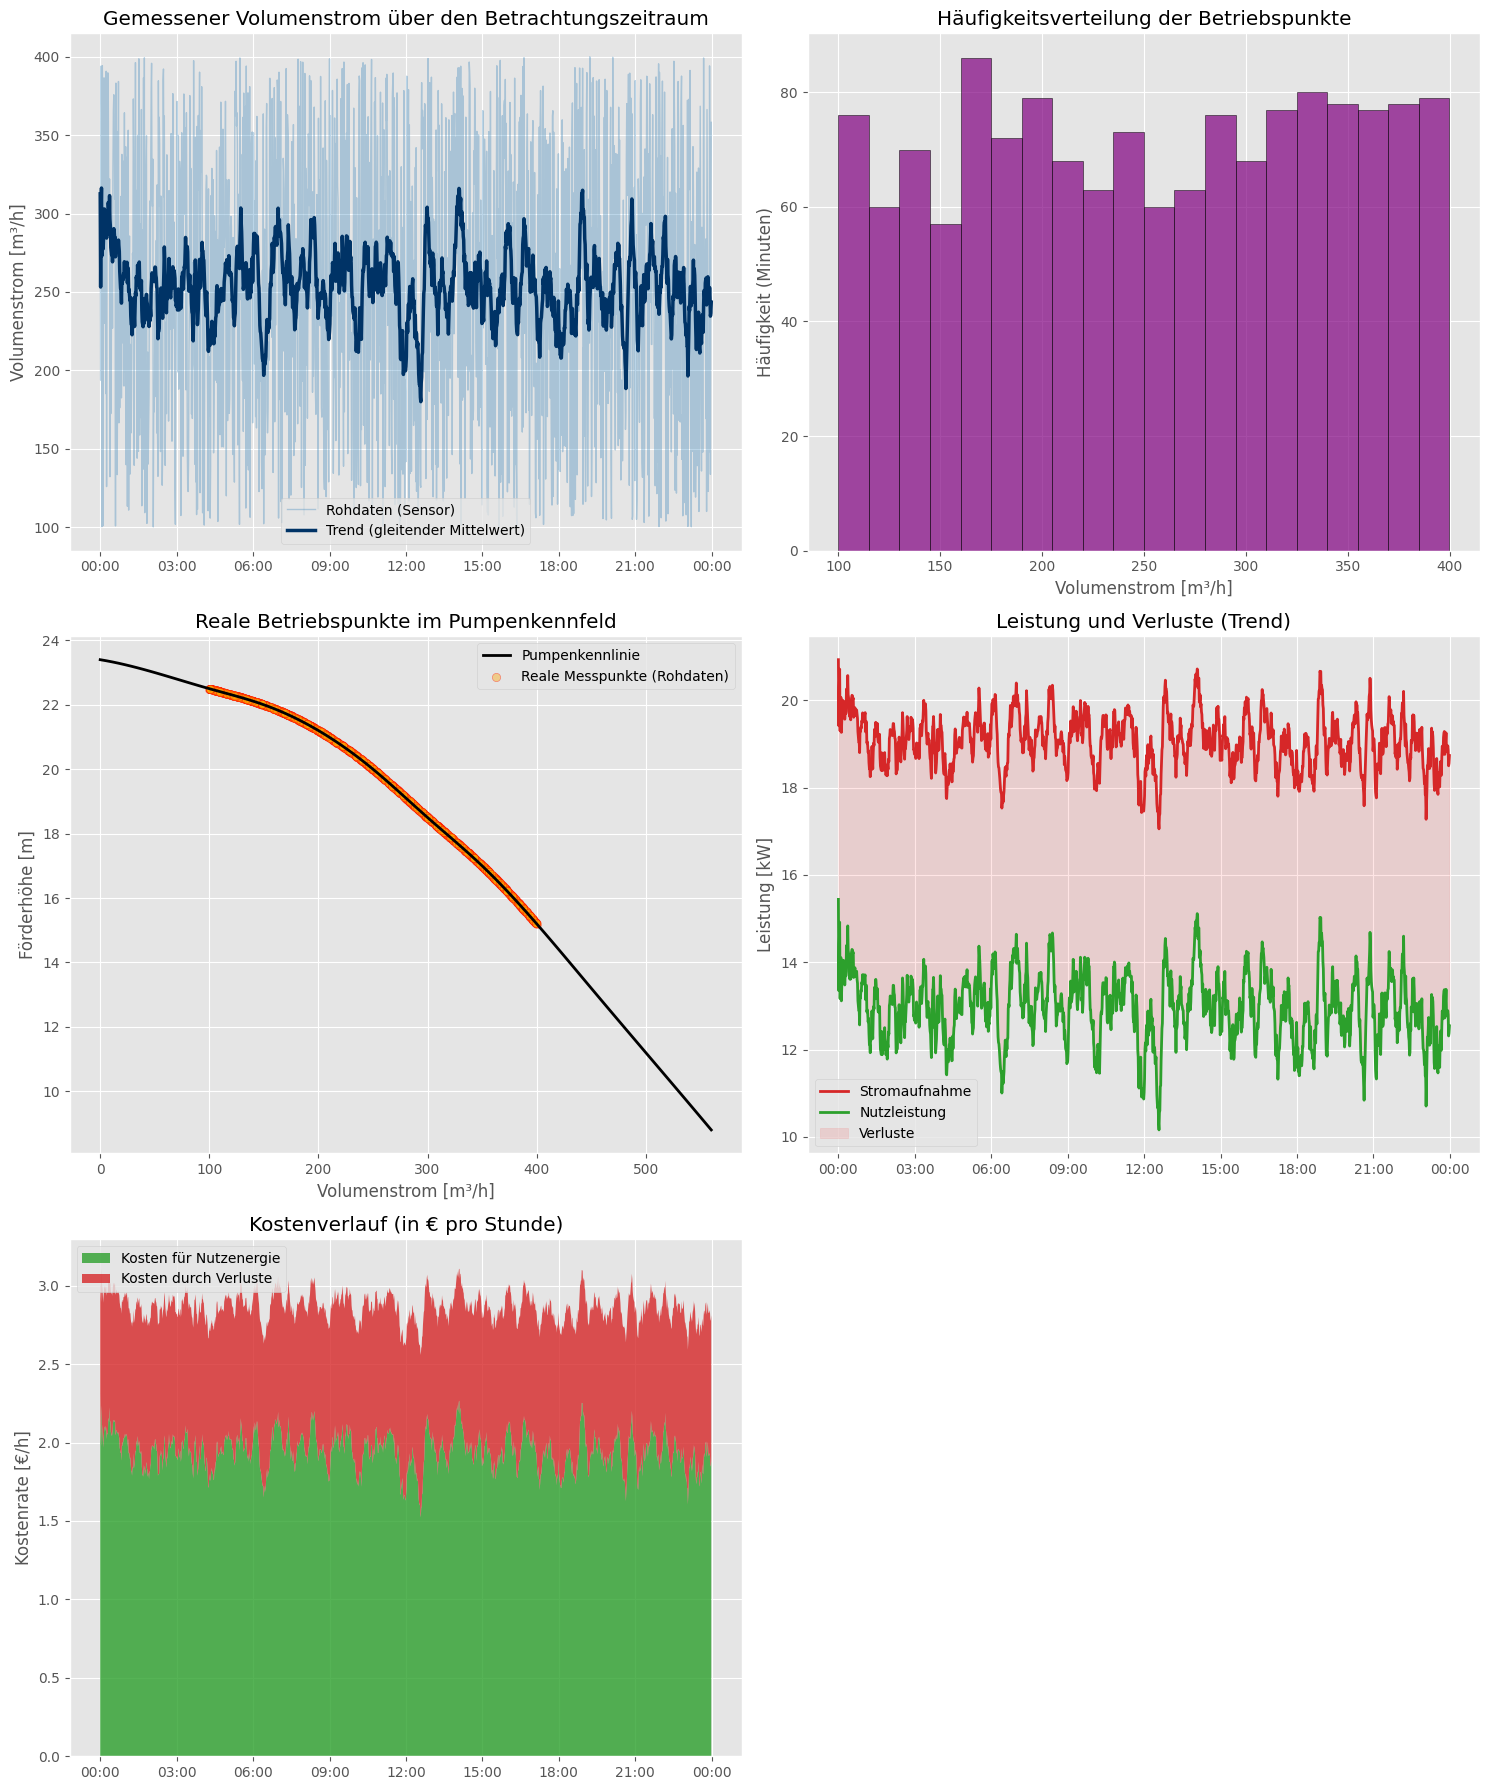

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------------------------------------------------------
# 5. Diagramme erstellen
# ---------------------------------------------------------
plt.style.use('ggplot')
fig, axs = plt.subplots(3, 2, figsize=(15, 18))

# Plot 1: Volumenstrom (Zeitverlauf)
axs[0, 0].plot(df['Timestamp'], df[col_flow], color='#1f77b4', alpha=0.3, linewidth=1, label='Rohdaten (Sensor)')
axs[0, 0].plot(df['Timestamp'], df['Q_smoothed'], color='#003366', linewidth=2.5, label='Trend (gleitender Mittelwert)')
axs[0, 0].set_title('Gemessener Volumenstrom über den Betrachtungszeitraum')
axs[0, 0].set_ylabel('Volumenstrom [m³/h]')
axs[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[0, 0].legend()

# Plot 2: Histogramm
axs[0, 1].hist(df[col_flow], bins=20, color='purple', alpha=0.7, edgecolor='black')
axs[0, 1].set_title('Häufigkeitsverteilung der Betriebspunkte')
axs[0, 1].set_xlabel('Volumenstrom [m³/h]')
axs[0, 1].set_ylabel('Häufigkeit (Minuten)')

# Plot 3: H-Q Kennfeld
Q_smooth_line = np.linspace(min(Q_points), max(Q_points), 100) # Use the range of provided Q_points
axs[1, 0].plot(Q_smooth_line, f_H(Q_smooth_line), color='black', linewidth=2, label='Pumpenkennlinie')
axs[1, 0].scatter(df[col_flow], df['H_m'], color='orange', alpha=0.4, edgecolor='red', label='Reale Messpunkte (Rohdaten)')
axs[1, 0].set_title('Reale Betriebspunkte im Pumpenkennfeld')
axs[1, 0].set_xlabel('Volumenstrom [m³/h]')
axs[1, 0].set_ylabel('Förderhöhe [m]')
axs[1, 0].legend()

# Plot 4: Leistungsvergleich (kW)
axs[1, 1].plot(df['Timestamp'], df['P_el_smooth']/1000, label='Stromaufnahme', color='#d62728', linewidth=2)
axs[1, 1].plot(df['Timestamp'], df['P_hyd_smooth']/1000, label='Nutzleistung', color='#2ca02c', linewidth=2)
axs[1, 1].fill_between(df['Timestamp'], df['P_hyd_smooth']/1000, df['P_el_smooth']/1000, color='red', alpha=0.1, label='Verluste')
axs[1, 1].set_title('Leistung und Verluste (Trend)')
axs[1, 1].set_ylabel('Leistung [kW]')
axs[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1, 1].legend()

# Plot 5: Stromkosten (Stacked Area)
axs[2, 0].stackplot(df['Timestamp'], df['Cost_hyd_smooth'], df['Cost_loss_smooth'],
                    labels=['Kosten für Nutzenergie', 'Kosten durch Verluste'],
                    colors=['#2ca02c', '#d62728'], alpha=0.8)
axs[2, 0].set_title('Kostenverlauf (in € pro Stunde)')
axs[2, 0].set_ylabel('Kostenrate [€/h]')
axs[2, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2, 0].legend(loc='upper left')

# Sechstes (leeres) Diagrammfeld ausblenden
axs[2, 1].axis('off')

plt.tight_layout()
plt.show()